# Exploration : Remplissage des matchs Paris Basketball

Question métier : quels matchs sous-performent en remplissage, et quels
leviers (tarification, campagnes, timing) pourraient corriger ça ?

Ce notebook explore `gold.fact_match`, construite par le pipeline
(`pipeline/gold/build_gold.py`), qui contient une ligne par match à domicile
avec le taux de remplissage, le contexte sportif, temporel et météo.

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

con = duckdb.connect("../data/warehouse/pbb.duckdb")
df = con.execute("SELECT * FROM gold.fact_match ORDER BY date").fetchdf()
print(f"{len(df)} matchs chargés")
df.head()

IOException: IO Error: Cannot open file "C:\Users\LENOVO\Documents\Workspace\pbb-project\data\warehouse\pbb.duckdb": Le processus ne peut pas accéder au fichier car ce fichier est utilisé par un autre processus.

File is already open in 
C:\Program Files\Python310\python.exe (PID 25960)

## 1. Vue d'ensemble du remplissage

In [ ]:
print(df['taux_remplissage'].describe())
print()
print("Par compétition :")
print(df.groupby('competition')['taux_remplissage'].agg(['mean', 'min', 'max', 'count']).round(3))

count    41.000000
mean      0.799683
std       0.124957
min       0.405000
25%       0.747000
50%       0.813000
75%       0.905000
max       0.951000
Name: taux_remplissage, dtype: float64

Par compétition :
                           mean    min    max  count
competition                                         
Betclic ÉLITE             0.746  0.405  0.886     15
Betclic ÉLITE - Playoffs  0.847  0.703  0.935      7
EuroLeague                0.825  0.560  0.951     19


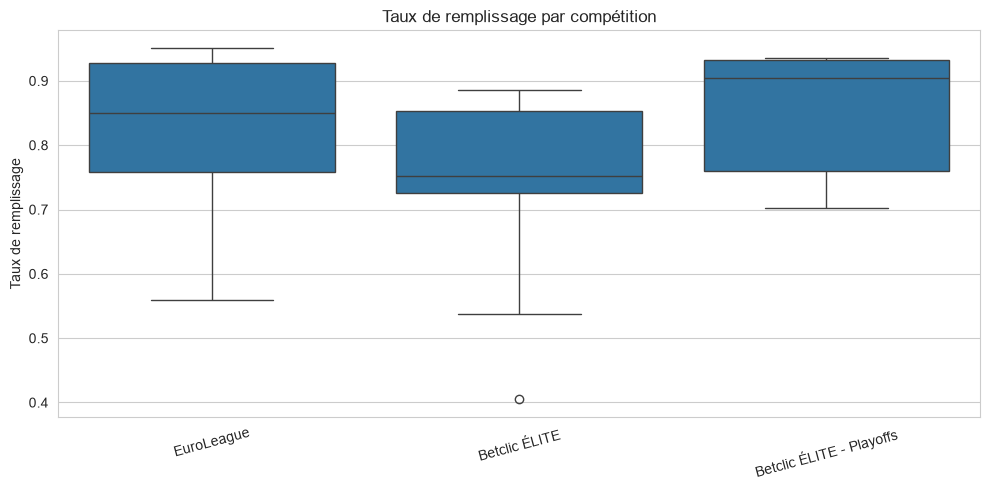

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='competition', y='taux_remplissage', ax=ax)
ax.set_title("Taux de remplissage par compétition")
ax.set_ylabel("Taux de remplissage")
ax.set_xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_par_competition.png", dpi=120)
plt.show()

## 2. Les matchs les plus faibles

Les 8 matchs avec le plus faible taux de remplissage, et leur contexte.

In [ ]:
cols = ['match_id', 'date', 'adversaire', 'competition', 'taux_remplissage',
        'rang_adversaire_avant', 'jour_semaine', 'vacances_scolaires', 'temperature']
df.nsmallest(8, 'taux_remplissage')[cols]

,match_id,date,adversaire,competition,taux_remplissage,rang_adversaire_avant,jour_semaine,vacances_scolaires,temperature
4,M005,2025-10-19,Dijon,Betclic ÉLITE,0.405,13,Sunday,True,13.3
10,M011,2025-12-07,Saint-Quentin,Betclic ÉLITE,0.538,14,Sunday,False,14.4
25,M026,2026-03-12,LDLC ASVEL Villeurbanne,EuroLeague,0.560,20,Thursday,False,10.5
11,M012,2025-12-09,Le Portel,Betclic ÉLITE,0.607,16,Tuesday,False,14.2
0,M001,2025-10-09,Virtus Bologna,EuroLeague,0.647,17,Thursday,False,15.9
2,M003,2025-10-15,Kosner Baskonia Vitoria-Gasteiz,EuroLeague,0.692,20,Wednesday,False,13.9
34,M035,2026-05-26,Strasbourg,Betclic ÉLITE - Playoffs,0.703,22,Tuesday,False,30.8
21,M022,2026-02-01,Boulazac,Betclic ÉLITE,0.711,12,Sunday,False,8.4


## 3. Le classement de l'adversaire a-t-il un effet ?

Hypothèse formée à l'oeil sur les données : un adversaire mal classé
(rang élevé) semble associé à un taux de remplissage plus faible.

In [ ]:
corr = df[['taux_remplissage', 'rang_adversaire_avant', 'rang_pbb_avant', 'ecart_classement']].corr()
print(corr['taux_remplissage'])

taux_remplissage         1.000000
rang_adversaire_avant   -0.625786
rang_pbb_avant           0.330336
ecart_classement        -0.623212
Name: taux_remplissage, dtype: float64


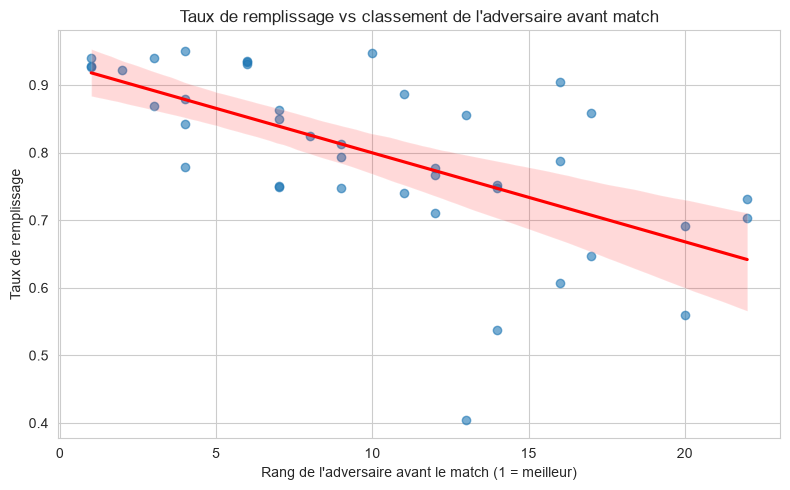

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='rang_adversaire_avant', y='taux_remplissage', ax=ax,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax.set_title("Taux de remplissage vs classement de l'adversaire avant match")
ax.set_xlabel("Rang de l'adversaire avant le match (1 = meilleur)")
ax.set_ylabel("Taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_remplissage_vs_classement.png", dpi=120)
plt.show()

## 4. Jour de semaine et vacances scolaires

In [ ]:
print(df.groupby('jour_semaine')['taux_remplissage'].agg(['mean', 'count']).round(3).sort_values('mean'))
print()
print(df.groupby('vacances_scolaires')['taux_remplissage'].agg(['mean', 'count']).round(3))

               mean  count
jour_semaine              
Sunday        0.748     10
Saturday      0.803      5
Thursday      0.810     12
Wednesday     0.813      2
Tuesday       0.819     11
Friday        0.947      1

                     mean  count
vacances_scolaires              
False               0.810     34
True                0.752      7


**Vérification** : l'effet "vacances scolaires" pourrait n'être qu'un
artefact si le calendrier programmait par coïncidence des adversaires plus
faibles pendant les vacances. On vérifie ici que ce n'est pas le cas.

In [ ]:
print(df.groupby('vacances_scolaires')['rang_adversaire_avant'].mean())

vacances_scolaires
False    10.088235
True      9.571429
Name: rang_adversaire_avant, dtype: float64


## 5. Prix moyen du billet vs remplissage

Le prix a-t-il été ajusté à la baisse pour les matchs à faible affluence
anticipée, ou est-ce un effet a posteriori (moins de monde = moins
d'abonnés, qui paient un tarif différent) ?

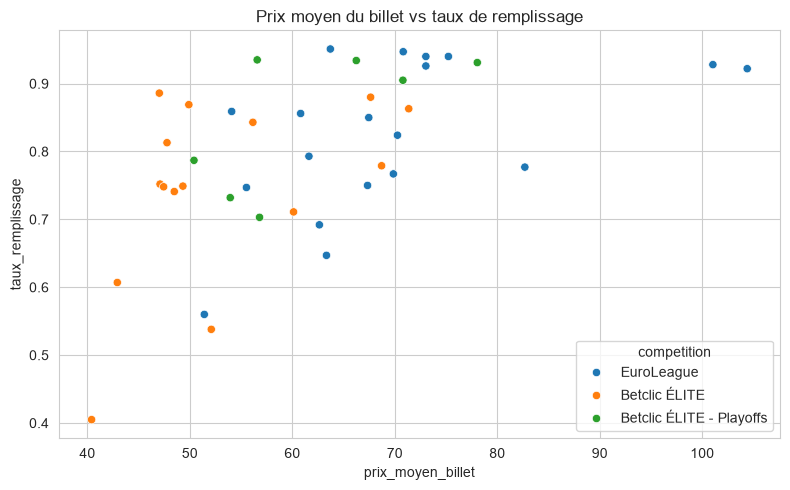

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='prix_moyen_billet', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Prix moyen du billet vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_prix_vs_remplissage.png", dpi=120)
plt.show()

## 6. Effet de la météo

La météo (température, précipitations) a été collectée pour chaque match
mais pas encore explorée. Vérifions si elle influence le remplissage.

In [ ]:
corr_meteo = df[['taux_remplissage', 'temperature', 'precipitation']].corr()
print(corr_meteo['taux_remplissage'])
print()
print("Matchs avec précipitations :", (df['precipitation'] > 0).sum())
print(df.groupby(df['precipitation'] > 0)['taux_remplissage'].agg(['mean', 'count']))

taux_remplissage    1.000000
temperature         0.037348
precipitation       0.024387
Name: taux_remplissage, dtype: float64

Matchs avec précipitations : 9
                   mean  count
precipitation                 
False          0.788188     32
True           0.840556      9


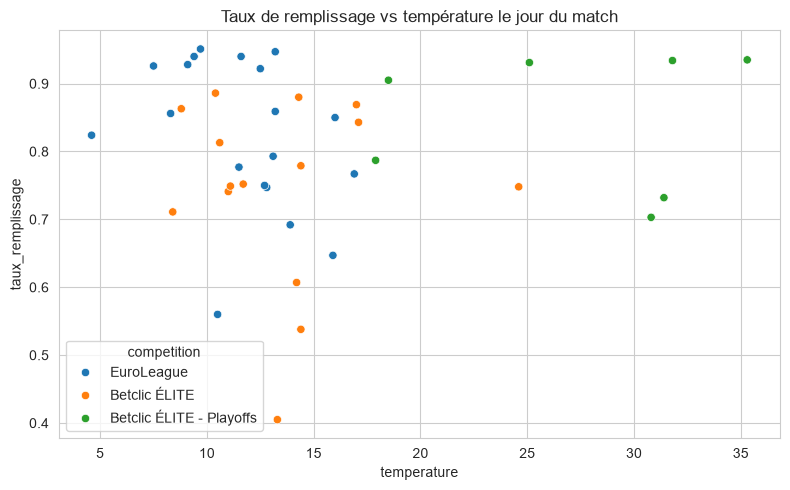

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='temperature', y='taux_remplissage', hue='competition', ax=ax)
ax.set_title("Taux de remplissage vs température le jour du match")
plt.tight_layout()
plt.savefig("../dashboard/fig_meteo_vs_remplissage.png", dpi=120)
plt.show()

## 7. Annulations et remplissage

Utilisation d'une donnée jusqu'ici inexploitée : les commandes annulées
(order_status_id) en billetterie brute, au-delà des seuls billets validés.

In [ ]:
corr_annulation = con.execute("""
    SELECT CORR(taux_remplissage, taux_annulation) AS correlation
    FROM gold.fact_match WHERE taux_annulation IS NOT NULL
""").fetchdf()
print(corr_annulation)
print()
print(df['taux_annulation'].describe())

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='taux_remplissage', y='taux_annulation', hue='competition', ax=ax)
ax.set_title("Taux d'annulation vs taux de remplissage")
plt.tight_layout()
plt.savefig("../dashboard/fig_annulation_vs_remplissage.png", dpi=120)
plt.show()

## 8. Synthèse

**Facteur dominant : le classement de l'adversaire.** Sur les 41 matchs de
la saison, le taux de remplissage chute nettement à mesure que l'adversaire
est mal classé (de ~90% pour un top adversaire à ~65% pour un adversaire en
bas de classement) -- effet visuellement très net (cf. graphique section 3).

**Écart marqué par compétition** : EuroLeague (82.5%) et Playoffs (84.7%)
remplissent mieux que le championnat national Betclic ÉLITE (74.6%) --
cohérent avec un attrait de marque/prestige plus fort pour l'Europe.

**Effet jour de semaine** : le dimanche est le jour le plus faible (74.8%,
sur 10 matchs), contre ~81-82% les mardis et jeudis.

**Effet vacances scolaires, contre-intuitif et vérifié** : les matchs
joués pendant les vacances scolaires remplissent moins bien (75.2%) que
hors vacances (81%). Vérification faite : ce n'est pas un biais de
calendrier (le rang moyen des adversaires est comparable dans les deux
groupes : 9.6 vs 10.1) -- l'effet semble donc réel, pas un artefact.

**Météo : aucun effet mesurable.** La température (corrélation 0.04) et les
précipitations (corrélation 0.02) n'expliquent pas les variations de
remplissage : contrairement à l'intuition, les matchs sous la pluie
remplissent même légèrement mieux (0.84 vs 0.79), écart probablement
non significatif vu le petit échantillon (9 matchs avec pluie).

### Recommandations actionnables

1. **Tarification dynamique par force d'adversaire** : les matchs contre
   des adversaires mal classés (rang > 15) pourraient bénéficier d'une
   politique tarifaire plus agressive (promotions, offres groupées) pour
   compenser l'attractivité sportive plus faible.
2. **Campagnes ciblées sur les dimanches et les périodes de vacances
   scolaires** : ces créneaux sous-performent systématiquement,
   indépendamment de la qualité de l'adversaire -- un axe marketing propre,
   pas juste un effet de calendrier sportif.
3. **Capitaliser sur les têtes d'affiche EuroLeague** dans la
   communication : l'écart de 8 points avec le championnat suggère un vrai
   effet de marque à exploiter (packaging d'abonnements orientés Europe ?).

### Limites

- 41 matchs seulement : les découpages par jour de semaine ou compétition
  reposent parfois sur de petits échantillons (ex : un seul match le
  vendredi) -- à interpréter avec prudence, pas comme des lois générales.
- L'effet "vacances scolaires" est observé mais sa cause reste à explorer
  (moins d'abonnés disponibles ? changement de public non-abonné ?) --  piste pour une future enquête satisfaction/comportement.